In [3]:
import pandas as pd
import requests

In [9]:
response = requests.get('https://www.alphavantage.co/query?function=FX_MONTHLY&from_symbol=EUR&to_symbol=USD&apikey=A8WH0BOBAPESJ073')

In [13]:
response.json()['Meta Data']

{'1. Information': 'Forex Monthly Prices (open, high, low, close)',
 '2. From Symbol': 'EUR',
 '3. To Symbol': 'USD',
 '4. Last Refreshed': '2026-05-08',
 '5. Time Zone': 'UTC'}

In [15]:
df = pd.read_csv('fx_monthly_EUR_USD.csv')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  230 non-null    object 
 1   open       230 non-null    float64
 2   high       230 non-null    float64
 3   low        230 non-null    float64
 4   close      230 non-null    float64
dtypes: float64(4), object(1)
memory usage: 9.1+ KB


In [19]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

In [21]:
df['SMA_3'] = df['close'].rolling(window=3).mean()
df['SMA_6'] = df['close'].rolling(window=6).mean()

In [31]:
# RSI(Momentum)=Relative Strength Index
def calc_rsi(data,window=14):
    delta = data.diff()
    gain = (delta.where(delta>0,0)).rolling(window=window).mean()
    loss = (-delta.where(delta<0,0)).rolling(window=window).mean()
    rs = gain/loss
    return 100 - (100/(1+rs))

In [33]:
df['RSI_14'] = calc_rsi(df['close'])

In [35]:
# Volatility Indicator
df['monthly_volatility'] = (df['high'] - df['low']) / df['open']

In [37]:
df['target'] = (df['close'].shift(-1) > df['close']).astype(int)

In [39]:
df_enriched = df.dropna()


In [41]:
df_enriched.to_csv('EUR_USD_Enriched.csv', index=False)
print("Enriched dataset saved! Upload 'EUR_USD_Enriched.csv' to Kaggle.")

Enriched dataset saved! Upload 'EUR_USD_Enriched.csv' to Kaggle.


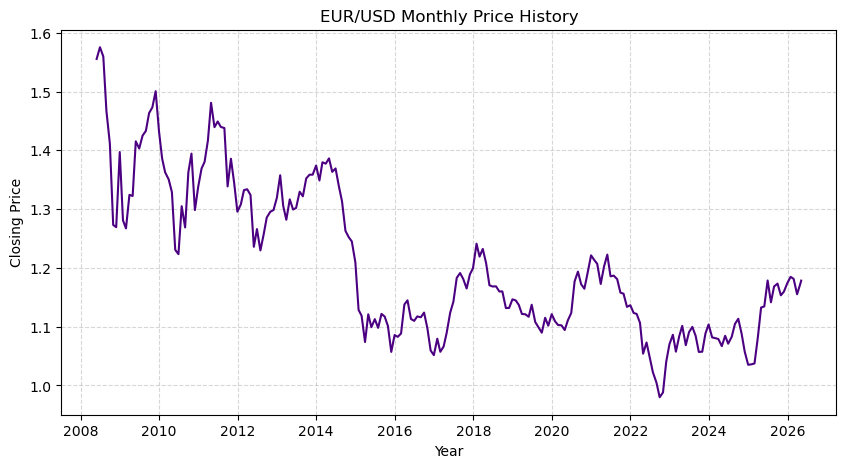

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df_enriched['timestamp'], df_enriched['close'], color='indigo', linewidth=1.5)
plt.title('EUR/USD Monthly Price History')
plt.xlabel('Year')
plt.ylabel('Closing Price')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()